In [8]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Load the saved data splits from Day 3
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

train_paths = data['train_paths']
val_paths = data['val_paths']
test_paths = data['test_paths']
train_labels = data['train_labels']
val_labels = data['val_labels']
test_labels = data['test_labels']
classes = data['classes']
class_to_idx = data['class_to_idx']

print("Data loaded successfully!")
print(f"Classes: {len(classes)}")
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Data loaded successfully!
Classes: 15
Train: 14453 | Val: 3088 | Test: 3096


In [9]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = PlantDiseaseDataset(train_paths, train_labels, transform=train_transform)
val_dataset = PlantDiseaseDataset(val_paths, val_labels, transform=val_transform)
test_dataset = PlantDiseaseDataset(test_paths, test_labels, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Datasets and DataLoaders ready!")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Datasets and DataLoaders ready!
Train batches: 452
Val batches:   97


In [10]:
# Load pretrained ResNet50
model = models.resnet50(weights='IMAGENET1K_V1')

# Freeze all layers - we don't want to change the pretrained weights yet
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# ResNet50's last layer is (2048 -> 1000) for ImageNet
# We change it to (2048 -> 15) for our 15 classes
num_classes = len(classes)
model.fc = nn.Linear(2048, num_classes)

# Only the new last layer will be trained
print("Model loaded and modified!")
print(f"\nFinal layer: {model.fc}")
print(f"\nTrainable parameters:")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total:     {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Frozen:    {total_params - trainable_params:,}")

Model loaded and modified!

Final layer: Linear(in_features=2048, out_features=15, bias=True)

Trainable parameters:
  Total:     23,538,767
  Trainable: 30,735
  Frozen:    23,508,032


In [11]:
# Loss function - standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer - only pass the trainable parameters
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# Learning rate scheduler - reduces lr by half every 5 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Device: {device}")
print(f"Loss function: {criterion}")
print(f"Optimizer: Adam with lr=0.001")
print(f"Scheduler: StepLR (halves lr every 5 epochs)")

Device: cpu
Loss function: CrossEntropyLoss()
Optimizer: Adam with lr=0.001
Scheduler: StepLR (halves lr every 5 epochs)


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track accuracy
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} "
                  f"| Loss: {running_loss/(batch_idx+1):.3f} "
                  f"| Acc: {100.*correct/total:.1f}%")

    return running_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total

print("Training functions defined!")

Training functions defined!


In [13]:
num_epochs = 3
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Starting training...\n")

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Step the scheduler
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'models/resnet50_best.pth')
        print(f"  ✓ New best model saved!")

    # Record history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\n  Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.3f} | Val Acc:   {val_acc:.1f}%")
    print()

print(f"Training complete! Best val accuracy: {best_val_acc:.1f}%")

Starting training...

Epoch 1/3
----------------------------------------
  Batch 50/452 | Loss: 1.964 | Acc: 43.6%
  Batch 100/452 | Loss: 1.596 | Acc: 56.1%
  Batch 150/452 | Loss: 1.395 | Acc: 61.8%
  Batch 200/452 | Loss: 1.241 | Acc: 66.1%
  Batch 250/452 | Loss: 1.134 | Acc: 68.8%
  Batch 300/452 | Loss: 1.053 | Acc: 70.8%
  Batch 350/452 | Loss: 0.996 | Acc: 72.2%
  Batch 400/452 | Loss: 0.943 | Acc: 73.6%
  Batch 450/452 | Loss: 0.901 | Acc: 74.7%
  ✓ New best model saved!

  Train Loss: 0.899 | Train Acc: 74.7%
  Val Loss:   0.456 | Val Acc:   87.2%

Epoch 2/3
----------------------------------------
  Batch 50/452 | Loss: 0.512 | Acc: 84.9%
  Batch 100/452 | Loss: 0.527 | Acc: 83.7%
  Batch 150/452 | Loss: 0.517 | Acc: 84.1%
  Batch 200/452 | Loss: 0.506 | Acc: 84.5%
  Batch 250/452 | Loss: 0.502 | Acc: 84.7%
  Batch 300/452 | Loss: 0.494 | Acc: 84.8%
  Batch 350/452 | Loss: 0.491 | Acc: 84.8%
  Batch 400/452 | Loss: 0.484 | Acc: 84.9%
  Batch 450/452 | Loss: 0.479 | Acc: 85.1

In [14]:
num_epochs = 3
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Resume from checkpoint if it exists
start_epoch = 0
checkpoint_path = 'models/checkpoint_latest.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accs = checkpoint['train_accs']
    val_accs = checkpoint['val_accs']
    print(f"Resumed from epoch {start_epoch}")
else:
    print("Starting fresh training...")

print("Starting training...\n")

for epoch in range(start_epoch, num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Print every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} "
                  f"| Loss: {running_loss/(batch_idx+1):.3f} "
                  f"| Acc: {100.*correct/total:.1f}%")

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Step scheduler
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'models/resnet50_best.pth')
        print(f"  ✓ New best model saved!")

    # Save checkpoint after every epoch
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_val_acc,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }, checkpoint_path)
    print(f"  ✓ Checkpoint saved!")

    # Record history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\n  Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.3f} | Val Acc:   {val_acc:.1f}%\n")

print(f"Training complete! Best val accuracy: {best_val_acc:.1f}%")

Starting fresh training...
Starting training...

Epoch 1/3
----------------------------------------
  Batch 10/452 | Loss: 0.440 | Acc: 85.6%
  Batch 20/452 | Loss: 0.354 | Acc: 89.1%
  Batch 30/452 | Loss: 0.375 | Acc: 87.9%
  Batch 40/452 | Loss: 0.369 | Acc: 88.2%
  Batch 50/452 | Loss: 0.366 | Acc: 88.1%
  Batch 60/452 | Loss: 0.370 | Acc: 87.7%
  Batch 70/452 | Loss: 0.368 | Acc: 87.5%
  Batch 80/452 | Loss: 0.377 | Acc: 87.0%
  Batch 90/452 | Loss: 0.376 | Acc: 86.9%
  Batch 100/452 | Loss: 0.371 | Acc: 87.2%
  Batch 110/452 | Loss: 0.373 | Acc: 87.4%
  Batch 120/452 | Loss: 0.375 | Acc: 87.3%
  Batch 130/452 | Loss: 0.375 | Acc: 87.5%
  Batch 140/452 | Loss: 0.367 | Acc: 87.7%
  Batch 150/452 | Loss: 0.369 | Acc: 87.5%
  Batch 160/452 | Loss: 0.370 | Acc: 87.5%
  Batch 170/452 | Loss: 0.372 | Acc: 87.5%
  Batch 180/452 | Loss: 0.373 | Acc: 87.3%
  Batch 190/452 | Loss: 0.373 | Acc: 87.3%
  Batch 200/452 | Loss: 0.373 | Acc: 87.3%
  Batch 210/452 | Loss: 0.372 | Acc: 87.3%
  Batc

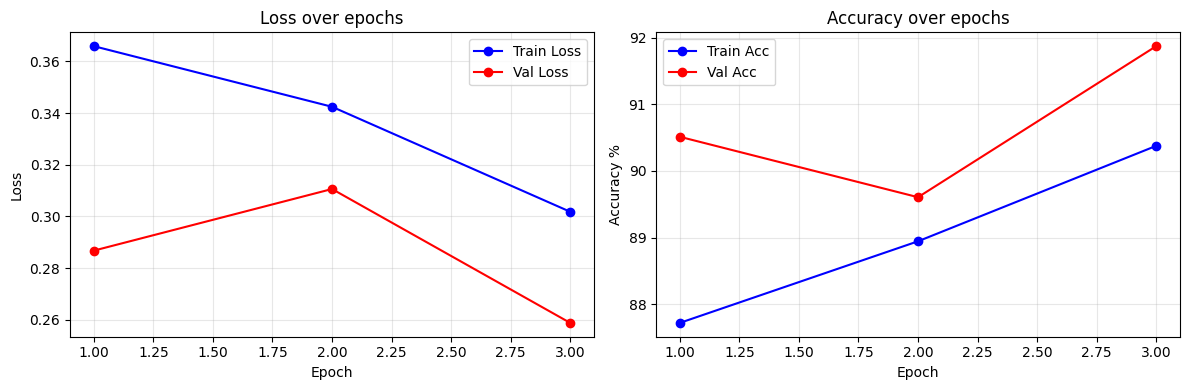

Saved to outputs/training_curves.png


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(range(1, 4), train_losses, 'b-o', label='Train Loss')
ax1.plot(range(1, 4), val_losses, 'r-o', label='Val Loss')
ax1.set_title('Loss over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(range(1, 4), train_accs, 'b-o', label='Train Acc')
ax2.plot(range(1, 4), val_accs, 'r-o', label='Val Acc')
ax2.set_title('Accuracy over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/training_curves.png")